# Loop vs Graph: the basics

The smallest example that shows the difference. Start here, then move to `loop_vs_graph.ipynb` for the production-shaped one.

> One person cooking dinner who also tastes their own dish: that is a **loop**. Do the thing, check the thing, try again if it is off.
> A kitchen where one preps, one cooks, and one only tastes and sends the plate back: that is a **graph**. Different jobs, different people, and someone whose only job is to check.

**The task.** Every morning an agent reads a few sources about a company, writes a short brief, and checks the brief is accurate before it goes out.

We build it three times, changing one thing each time:

| Step | Build | What changes |
|---|---|---|
| 1 | **The loop** | One agent, one context. It reads, writes, and reviews its own draft. |
| 2 | **The loop, with fresh eyes** | Same loop. The reviewer no longer sees the agent's own context. |
| 3 | **The graph** | Three nodes: researchers in parallel, a writer, a reviewer. State flows between them. |

**About the "model".** There is no LLM in this notebook. The three skills an agent needs (research, write, review) are a few lines of plain Python each, so you can read exactly why each one does what it does, and every run gives the same result. The *same three functions* are used by every build. The only thing that changes between builds is **the structure, and what each step is allowed to see**. That is the whole lesson.

The example and the framing follow two DevCompass articles, which are worth reading alongside this: [Loop Engineering vs. Graph Engineering, Part 1](https://www.devcompass.ai/blog/loop-engineering-vs-graph-engineering-part-1) and [Part 2: Building It in Code](https://www.devcompass.ai/blog/loop-engineering-vs-graph-engineering-part-2-building-it-in-code).

In [1]:
# Fresh environment? Uncomment and run once, then restart the kernel.
# %pip install -q "langgraph>=1.0" "langchain-core>=1.0"

In [2]:
import re
import time
from typing import Annotated, TypedDict

---
# 1. The task

Three web pages about a (fictional) company, Kovai Motors. They look the way real pages look: the facts are in there, and so is junk. A sponsored line with somebody's forecast. A "related" link with last year's number.

`TRUTH` is what a correct brief must say. The agents never see it. It is our answer key, used only to grade what they ship.

In [3]:
PAGES = {
    "filing": """KOVAI MOTORS LTD - RESULTS FOR Q2
Revenue from operations was Rs 480 crore.
Net profit was Rs 36 crore.
The board approved a second plant in Hosur.""",

    "news": """HOME | MARKETS | AUTO | SUBSCRIBE
Kovai Motors reported Q2 revenue of Rs 480 crore, up 12% from a year ago.
Net profit for the quarter was Rs 36 crore.
SPONSORED: QuickTips analysts expect Kovai Motors profit of Rs 52 crore next quarter. Click here.""",

    "blog": """AutoWatch Weekly
Kovai Motors will open a second plant in Hosur in 2027.
RELATED: Flashback to 2024, when Kovai Motors revenue was Rs 410 crore.
Share this post | 14 comments""",
}

TRUTH = {"revenue": "480", "profit": "36"}


def fetch(source: str) -> str:
    """Pretend to download a page. The sleep stands in for network latency."""
    time.sleep(0.4)
    return f"[{source}]\n{PAGES[source]}"


def grade(brief: str) -> None:
    """Our answer key. The agents never call this."""
    checks = {
        f"revenue is Rs {TRUTH['revenue']} crore": f"Rs {TRUTH['revenue']} crore" in brief,
        f"profit is Rs {TRUTH['profit']} crore": f"Rs {TRUTH['profit']} crore" in brief,
        "no unsupported claims": "fastest" not in brief,
    }
    for name, ok in checks.items():
        print(f"   {'PASS' if ok else 'FAIL'}  {name}")
    print("   => the brief is", "CORRECT" if all(checks.values()) else "WRONG")

---
# 2. The three skills

In a real system each of these is an LLM call with its own prompt. Here each is a caricature of how a model behaves, small enough to read in one go.

| Skill | What it does | Its weakness |
|---|---|---|
| `research(page)` | Pulls out the facts a page itself reports, as structured notes. Skips ads and sidebars. | None here. It has one narrow job. |
| `write(material)` | Writes the brief from whatever material it is handed. | For each figure it grabs the **most recent mention** in its material. And it likes to end on a punchy line nobody gave it. |
| `review(draft, evidence)` | Passes a sentence only if its amounts and key words can be found in the evidence. | It can only be as good as the evidence it is handed. |

Every call is logged with the size of the context it saw. We will use that log at the end.

In [4]:
CALLS = []      # one row per skill call: which build, which skill, how much context it saw
BUILD = "?"     # set by each run so the log knows who is calling


def log(skill: str, context: str) -> None:
    CALLS.append({"build": BUILD, "skill": skill, "context_chars": len(context)})


def start(build: str) -> float:
    """Name the build that is about to run, forget its earlier rows, start the clock."""
    global BUILD
    BUILD = build
    CALLS[:] = [c for c in CALLS if c["build"] != build]
    return time.time()


def research(page: str) -> list[dict]:
    """One job: structured notes on what the source itself reports. Output is data, not prose."""
    log("research", page)
    source = page.split("]")[0].strip("[")
    notes = []
    for line in page.splitlines()[1:]:
        if re.match(r"[A-Z]+:", line):                  # SPONSORED:, RELATED: ... not the source's own reporting
            continue
        money = re.search(r"Rs (\d+) crore", line)
        if money and "revenue" in line.lower():
            notes.append({"field": "revenue", "value": money.group(1), "quote": line, "source": source})
        elif money and "profit" in line.lower():
            notes.append({"field": "profit", "value": money.group(1), "quote": line, "source": source})
        elif "plant in Hosur" in line:
            notes.append({"field": "plant", "value": "Hosur", "quote": line, "source": source})
    return notes


FLOURISH = "This makes it the fastest growing automaker in the south."


def write(material: str, feedback: list[str]) -> str:
    """Writes from whatever it is handed. Drops any sentence the reviewer rejected last time."""
    log("write", material)

    def latest(field):                                  # the most recent mention wins
        found = re.findall(field + r"[^.\n]*?Rs (\d+) crore", material, re.I)
        return found[-1] if found else "?"

    sentences = [
        f"Kovai Motors Q2 revenue was Rs {latest('revenue')} crore.",
        f"Net profit was Rs {latest('profit')} crore.",
    ]
    if "Hosur" in material:
        sentences.append("A second plant in Hosur is planned.")
    sentences.append(FLOURISH)                          # nobody asked for this
    return " ".join(s for s in sentences if s not in feedback)


def review(draft: str, evidence: str) -> dict:
    """A sentence is supported if all its amounts, and at least half its long words, appear in the evidence."""
    log("review", evidence)
    unsupported = []
    for sentence in re.findall(r"[^.]+\.", draft):
        sentence = sentence.strip()
        amounts = re.findall(r"Rs \d+ crore", sentence)
        words = [w.lower() for w in re.findall(r"[A-Za-z]{6,}", sentence)]
        amounts_ok = all(a in evidence for a in amounts)
        words_ok = sum(w in evidence.lower() for w in words) * 2 >= len(words)
        if not (amounts_ok and words_ok):
            unsupported.append(sentence)
    return {"passed": not unsupported, "unsupported": unsupported}

Try each skill on its own before wiring anything together.

In [5]:
start("scratch")
page = fetch("news")
print(page, "\n")

for note in research(page):
    print(note)

[news]
HOME | MARKETS | AUTO | SUBSCRIBE
Kovai Motors reported Q2 revenue of Rs 480 crore, up 12% from a year ago.
Net profit for the quarter was Rs 36 crore.
SPONSORED: QuickTips analysts expect Kovai Motors profit of Rs 52 crore next quarter. Click here. 

{'field': 'revenue', 'value': '480', 'quote': 'Kovai Motors reported Q2 revenue of Rs 480 crore, up 12% from a year ago.', 'source': 'news'}
{'field': 'profit', 'value': '36', 'quote': 'Net profit for the quarter was Rs 36 crore.', 'source': 'news'}


The researcher skipped the `SPONSORED` line. Now hand the writer two different materials: the raw page, and the clean notes. **Same function, different input.**

In [6]:
def notes_as_text(notes: list[dict]) -> str:
    return "\n".join(f"{n['field']}: Rs {n['value']} crore  ({n['source']}: \"{n['quote']}\")" if n["field"] != "plant"
                     else f"plant: {n['value']}  ({n['source']}: \"{n['quote']}\")" for n in notes)


print("from the raw page:   ", write(page, feedback=[]))
print("from the clean notes:", write(notes_as_text(research(page)), feedback=[]))

from the raw page:    Kovai Motors Q2 revenue was Rs 480 crore. Net profit was Rs 52 crore. This makes it the fastest growing automaker in the south.
from the clean notes: Kovai Motors Q2 revenue was Rs 480 crore. Net profit was Rs 36 crore. This makes it the fastest growing automaker in the south.


From the raw page the writer reports a profit of 52: the sponsored forecast was the most recent mention. From the notes it gets 36.

Nothing about the writer changed. **What it could see changed.** Hold that thought.

---
# 3. Build 1: the loop

One agent. One context. Four steps and a stop condition:

```
discover -> execute -> verify -> (passed? stop : update and repeat)
```

Read `run_loop` and watch the variable called `context`. Everything lands in it: each raw page as it is fetched, then the draft. And when it is time to verify, the agent reviews its draft **against that same context**.

Two details matter more than they look:

- **`review` is doing the real work, not `write`.** If the verifier always passes, the loop is decoration. It returns a wrong answer on the first try and calls it done.
- **`max_iterations` is not a formality.** A loop with no ceiling and a verifier that never quite passes burns budget until something else stops it.

In [7]:
def run_loop(fresh_eyes: bool = False, max_iterations: int = 3) -> str:
    started = start("loop + fresh eyes" if fresh_eyes else "loop")

    context = []                                    # ONE context. Everything lands here.
    for source in PAGES:                            # discover: one source at a time
        context.append(fetch(source))
    pages_only = "\n".join(context)
    print(f"  discover   read {len(PAGES)} pages one after another   {time.time() - started:.1f}s")

    feedback = []
    for i in range(1, max_iterations + 1):
        draft = write("\n".join(context), feedback)             # execute
        context.append(f"[my draft {i}]\n{draft}")

        evidence = pages_only if fresh_eyes else "\n".join(context)
        verdict = review(draft, evidence)                        # verify
        print(f"  iteration {i}  review {'PASSED' if verdict['passed'] else 'REJECTED ' + str(verdict['unsupported'])}")

        if verdict["passed"]:
            return draft
        feedback = verdict["unsupported"]                        # update and repeat

    raise RuntimeError("hit max_iterations without passing review")

In [8]:
brief = run_loop()
print("\nSHIPPED:", brief, "\n")
grade(brief)

  discover   read 3 pages one after another   1.2s
  iteration 1  review PASSED

SHIPPED: Kovai Motors Q2 revenue was Rs 410 crore. Net profit was Rs 52 crore. A second plant in Hosur is planned. This makes it the fastest growing automaker in the south. 

   FAIL  revenue is Rs 480 crore
   FAIL  profit is Rs 36 crore
   FAIL  no unsupported claims
   => the brief is WRONG


The review **passed on the first try**, and the brief is wrong three ways: last year's revenue, somebody's profit forecast, and a closing line that no source supports.

The loop is not broken. Every step did its job. Look at what the reviewer was handed:

In [9]:
last_review = [c for c in CALLS if c["build"] == "loop" and c["skill"] == "review"][-1]
print("the reviewer's evidence was", last_review["context_chars"], "characters: every raw page, plus the draft it was supposed to check")
print()
print("'Rs 410 crore' is in the evidence (the RELATED link)  -> revenue looks supported")
print("'Rs 52 crore' is in the evidence (the SPONSORED line) -> profit looks supported")
print("'fastest growing' is in the evidence (the draft!)     -> the flourish looks supported")

the reviewer's evidence was 772 characters: every raw page, plus the draft it was supposed to check

'Rs 410 crore' is in the evidence (the RELATED link)  -> revenue looks supported
'Rs 52 crore' is in the evidence (the SPONSORED line) -> profit looks supported
'fastest growing' is in the evidence (the draft!)     -> the flourish looks supported


That is **an agent grading its own homework with the answer key still open.** By the time review happens the context is a swamp of raw pages and the agent's own output, and anything the agent wrote is, by construction, "in the context".

A loop with a weak verifier does not fail loudly. It quietly ships wrong answers with full confidence.

---
# 4. One change: fresh eyes

Do not reach for a graph yet. Make the smallest change that could help.

Same loop, same skills. The only difference is one line: the reviewer's evidence is now **the source pages only**, not the agent's whole context. It no longer sees the draft it is checking, or anything else the agent wrote.

In [10]:
brief = run_loop(fresh_eyes=True)
print("\nSHIPPED:", brief, "\n")
grade(brief)

  discover   read 3 pages one after another   1.2s
  iteration 1  review REJECTED ['This makes it the fastest growing automaker in the south.']
  iteration 2  review PASSED

SHIPPED: Kovai Motors Q2 revenue was Rs 410 crore. Net profit was Rs 52 crore. A second plant in Hosur is planned. 

   FAIL  revenue is Rs 480 crore
   FAIL  profit is Rs 36 crore
   PASS  no unsupported claims
   => the brief is WRONG


Progress. The reviewer **rejected** the first draft, the loop went round again, and the flourish is gone. That is the loop doing what loops are good at: try, check, fix, repeat.

But the numbers are still wrong, and the reviewer passed them. It had to: `410` and `52` really are on those pages. An independent reviewer cannot catch an error that is *also in its evidence*.

So there are two separate problems, and fresh eyes only fixed one:

| Problem | Cause | Fixed by |
|---|---|---|
| Unsupported flourish survives review | The reviewer could see the draft | A reviewer with its own context |
| Wrong numbers | The writer works from raw, noisy pages | Giving the writer clean material |

The second fix needs someone whose only job is to turn raw pages into clean notes. That is a second specialist, and now we are talking about a graph.

---
# 5. Build 2: the graph

Three specialists, with state flowing between them:

```
            +-> researcher (filing) -+
START ------+-> researcher (news)   -+--> writer --> reviewer --> END
            +-> researcher (blog)   -+        ^          |
                                              +- reject -+
```

- **Researchers** run in parallel, one per source. Each returns structured notes. They never write prose.
- **The writer** sees only the merged notes. Never a raw page.
- **The reviewer** runs with fresh eyes: the notes and the finished draft, nothing else. If the draft fails, it routes back to the writer.

This part uses LangGraph. Nothing above needed it.

In [11]:
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send

## 5.1 State, and the fan-in

In the loop, state lived inside one agent's context. In a graph it is explicit: a small typed dict that travels along the edges. Each node reads what it needs and returns only what it changed.

Three researchers will write to `notes` at the same time, so `notes` needs a rule for combining them. That rule is `merge_notes`, and it is **plain code**: append, and drop duplicates (the filing and the news page both report revenue of 480). No model call, no tokens. Combining results is often the cheapest part of a graph. It only deserves an agent when "combine these" really means "read all of these and decide what matters".

In [12]:
def merge_notes(existing: list[dict], new: list[dict]) -> list[dict]:
    """The fan-in. Plain code: append, skip facts we already have."""
    seen = {(n["field"], n["value"]) for n in existing}
    return existing + [n for n in new if (n["field"], n["value"]) not in seen]


class BriefState(TypedDict, total=False):
    notes: Annotated[list[dict], merge_notes]      # several researchers write here; merge_notes combines them
    draft: str
    verdict: dict
    feedback: list[str]
    revisions: int

## 5.2 The nodes

Each node is a function with a contract: it takes the state, does **one job**, and returns structured data. Look at what each one reads.

- `researcher` reads one source name. It returns notes, not prose.
- `writer` reads `notes` and `feedback`. It has no way to see a raw page.
- `reviewer` reads `notes` and `draft`. It has no way to see how the draft was produced.

They call the same `research`, `write` and `review` skills the loop used.

In [13]:
def researcher(task: dict) -> BriefState:
    return {"notes": research(fetch(task["source"]))}


def writer(state: BriefState) -> BriefState:
    draft = write(notes_as_text(state["notes"]), state.get("feedback", []))
    return {"draft": draft, "revisions": state.get("revisions", 0) + 1}


def reviewer(state: BriefState) -> BriefState:
    verdict = review(state["draft"], evidence=notes_as_text(state["notes"]))
    print(f"  reviewer   draft {state['revisions']}  {'PASSED' if verdict['passed'] else 'REJECTED ' + str(verdict['unsupported'])}")
    return {"verdict": verdict, "feedback": verdict["unsupported"]}

## 5.3 The routing

Two routers, both plain Python.

`fan_out` returns one `Send` per source. That is how a graph says "run this node several times, in parallel, each with its own input".

`after_review` is the reject-and-revise edge. The *judgment* (is this draft accurate?) happened inside the reviewer node. The *routing* is an `if` on a field. It behaves the same way every time, and you can read it without running anything. The revision cap is this graph's `max_iterations`.

In [14]:
MAX_REVISIONS = 3


def fan_out(state: BriefState) -> list[Send]:
    return [Send("researcher", {"source": source}) for source in PAGES]


def after_review(state: BriefState) -> str:
    if state["verdict"]["passed"] or state["revisions"] >= MAX_REVISIONS:
        return END
    return "writer"

## 5.4 Wiring, and the picture

A declared structure is one you can draw. Dotted arrows are routing decisions, solid arrows are fixed. LangGraph draws `researcher` as one box. At run time `fan_out` starts one copy of it per source, which is the fan-out in the sketch above. (The picture is rendered by the public mermaid.ink service. Offline, the cell prints Mermaid source you can paste into [mermaid.live](https://mermaid.live).)

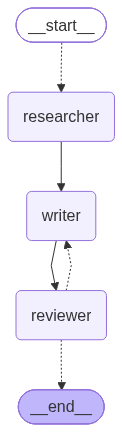

In [15]:
def show(app):
    g = app.get_graph()
    try:
        from IPython.display import Image, display
        display(Image(g.draw_mermaid_png()))
    except Exception:
        print(g.draw_mermaid())


g = StateGraph(BriefState)
g.add_node("researcher", researcher)
g.add_node("writer", writer)
g.add_node("reviewer", reviewer)

g.add_conditional_edges(START, fan_out, ["researcher"])      # fan-out: one researcher per source, in parallel
g.add_edge("researcher", "writer")                           # fan-in: writer waits for all of them
g.add_edge("writer", "reviewer")
g.add_conditional_edges("reviewer", after_review, ["writer", END])   # reject -> revise

brief_graph = g.compile()
show(brief_graph)

## 5.5 Run it

In [16]:
started = start("graph")
result = brief_graph.invoke({"notes": []})
print(f"  total      {time.time() - started:.1f}s")

print("\nNOTES the writer saw:")
print(notes_as_text(result["notes"]))
print("\nSHIPPED:", result["draft"], "\n")
grade(result["draft"])

  reviewer   draft 1  REJECTED ['This makes it the fastest growing automaker in the south.']
  reviewer   draft 2  PASSED
  total      0.4s

NOTES the writer saw:
revenue: Rs 480 crore  (filing: "Revenue from operations was Rs 480 crore.")
profit: Rs 36 crore  (filing: "Net profit was Rs 36 crore.")
plant: Hosur  (filing: "The board approved a second plant in Hosur.")

SHIPPED: Kovai Motors Q2 revenue was Rs 480 crore. Net profit was Rs 36 crore. A second plant in Hosur is planned. 

   PASS  revenue is Rs 480 crore
   PASS  profit is Rs 36 crore
   PASS  no unsupported claims
   => the brief is CORRECT


Correct on all three, and you can see each fix working:

- **The numbers are right** because the writer never saw the junk. The researchers filtered it out, and `merge_notes` removed the duplicate.
- **The flourish was caught** by a reviewer that could not see the draft's history. It rejected draft 1, the edge routed back to the writer, draft 2 passed.
- **Research took about a third of the time.** Three researchers ran side by side. A loop is sequential by shape.

---
# 6. A loop is a graph with one node

You did not throw the loop away. Here is build 1 again, written as a graph: **one node with an edge pointing back at itself.**

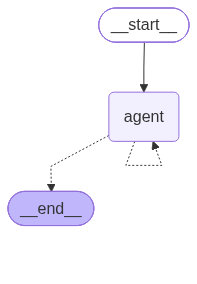

SHIPPED: Kovai Motors Q2 revenue was Rs 410 crore. Net profit was Rs 52 crore. A second plant in Hosur is planned. This makes it the fastest growing automaker in the south. 

   FAIL  revenue is Rs 480 crore
   FAIL  profit is Rs 36 crore
   FAIL  no unsupported claims
   => the brief is WRONG


In [17]:
class LoopState(TypedDict, total=False):
    context: list[str]
    draft: str
    passed: bool
    iterations: int


def agent(state: LoopState) -> LoopState:
    context = state.get("context") or [fetch(source) for source in PAGES]
    draft = write("\n".join(context), [])
    context = context + [draft]
    passed = review(draft, "\n".join(context))["passed"]      # same context: it grades its own homework
    return {"context": context, "draft": draft, "passed": passed, "iterations": state.get("iterations", 0) + 1}


def again(state: LoopState) -> str:
    return END if state["passed"] or state["iterations"] >= 3 else "agent"


lg = StateGraph(LoopState)
lg.add_node("agent", agent)
lg.add_edge(START, "agent")
lg.add_conditional_edges("agent", again, ["agent", END])
loop_as_graph = lg.compile()
show(loop_as_graph)

start("loop as a 1-node graph")
out = loop_as_graph.invoke({})
print("SHIPPED:", out["draft"], "\n")
grade(out["draft"])

Same wrong brief. **Drawing a loop as a graph changes nothing.** The framework is not what fixed build 2. What fixed it was separate contexts, a fan-out, and an independent reviewer.

It also runs the other way. Every node in build 2 could itself be a small loop (the writer could draft, self-check and retry before handing over). Graph engineering does not replace loop engineering. It composes loops and adds a layer on top: the topology, and the routing between the pieces.

---
# 7. Side by side

In [18]:
from IPython.display import Markdown, display

outcome = {
    "loop": "wrong numbers, flourish shipped",
    "loop + fresh eyes": "wrong numbers, flourish caught",
    "graph": "correct",
}
rows = ["| build | skill calls | biggest context any call saw | what the reviewer saw | shipped |", "|---|---:|---:|---:|---|"]
for build in outcome:
    calls = [c for c in CALLS if c["build"] == build]
    reviews = [c["context_chars"] for c in calls if c["skill"] == "review"]
    rows.append(f"| {build} | {len(calls)} | {max(c['context_chars'] for c in calls)} chars | {max(reviews)} chars | {outcome[build]} |")
display(Markdown("\n".join(rows)))

| build | skill calls | biggest context any call saw | what the reviewer saw | shipped |
|---|---:|---:|---:|---|
| loop | 2 | 772 chars | 772 chars | wrong numbers, flourish shipped |
| loop + fresh eyes | 4 | 772 chars | 595 chars | wrong numbers, flourish caught |
| graph | 7 | 256 chars | 207 chars | correct |

The graph made **more** calls and shipped the only correct brief. Each call saw **less**. That is the trade: more moving parts and more code, in exchange for small clean contexts, a check that is actually independent, and parallel research.

| | Loop | Graph |
|---|---|---|
| **Unit** | One agent's cycle | Several nodes, edges and shared state |
| **State** | Lives inside one agent's context | Flows along the edges, shared between nodes |
| **You design** | The cycle and its stop condition | The topology and the routing |
| **Fails when** | The verifier is weak | The topology is wrong, or state leaks between nodes |

---
# 8. When is it worth it?

**Most tasks are still one well-scoped loop.** If the sources here had been clean, build 1 with fresh eyes would have been enough, with less code and nothing to install. Start with a loop. Write the verifier before you write the prompt. Add a node when the work demands it.

## Did you actually change paradigms? A gut check

Four questions, asked of build 2:

| | Question | Build 2 |
|---|---|---|
| 1 | Did you split one context into genuinely separate, specialised ones? | Yes. The writer never sees a raw page. The reviewer never sees the process. |
| 2 | Is there a real fan-out and fan-in? | Yes. Three researchers in parallel, merged by `merge_notes`. |
| 3 | Can you read the control flow as a diagram? | Yes. "If review fails, go back" is `after_review`, defined up front. |
| 4 | Did the success bar change? | No. "Accurate against the sources" is the same bar as before. |

Zero or one yes: you have a loop wearing a graph diagram. Keep it a loop (section 6 is exactly that). Two or three: you are composing loops into a graph and the extra cost is earning its keep.

## Signals that a loop is straining

- The work splits into **distinct specialities**, not just phases of one job.
- There is real **independent work to fan out and merge**.
- Different steps want **different models, tools or contexts**, and sharing one is hurting quality.
- You need **control flow you can hand to a teammate as a diagram**.

When it is time, start the way section 4 did: **pull the verifier out first.** It fixes the most common failure before you commit to a whole topology.

## One caution

Our reviewer is only as good as its evidence. In build 2 it trusts the notes completely. If a researcher got something wrong, the writer would repeat it and the reviewer would wave it through: everything consistent, nothing verified. A graph of checkers still needs an anchor in reality. Ours is `grade()`. In production it is tests that actually ran, revenue that actually landed, a human who signs off.

## Exercises

1. **Break the researcher.** Delete the two lines in `research` that skip `SPONSORED:` and `RELATED:` lines. Re-run the graph. What ships? Which node would you add to defend against a bad researcher?
2. **A fourth source.** Add a page to `PAGES`. What had to change in the loop? In the graph? Time both.
3. **Remove the ceiling.** Make `write` ignore its feedback, then set `MAX_REVISIONS = 50`. What happens, and what would it cost with a real model? Now do the same to the loop's `max_iterations`.
4. **A loop inside a node.** Give the `writer` node its own small loop: draft, check the draft has no sentence without a number or a place name, retry up to twice, then hand over. Does the reviewer still reject draft 1?
5. **Is it an edge or a node?** `merge_notes` dedupes on exact match. Suppose one source says "Rs 480 crore" and another "Rs 4.8 billion". Is merging still plain code, or does it now need judgment?

## Where next

`loop_vs_graph.ipynb` takes the same question to a production-shaped task (accounts payable, with a real model behind it). There the loop is a model choosing its own tool calls, and the reasons to reach for a graph are different again: an irreversible action, a human who has to approve and is not online, retries that should not cost tokens, and a branch nobody drew.